In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, ListedColormap
import h5py
import pandas as pd

!pip3 install h5flow
import h5flow
from h5flow.data import dereference

In [3]:
int_to_height = 8.33
bin_size_cm = 2.5
threshold_acl = 1 / int_to_height
threshold_lcm = 1 / int_to_height

#filename = '~/dune/light_file_processing/outputs/mr6-5_no_th/truth_reco_match_n1000.csv'
#filename = '~/dune/light_file_processing/gnn_outputs/inputs_1000_files.csv'
filename = '/pscratch/sd/j/jvmead/to_dataframes/truth_reco_match_n1000_opt.csv'
df_truth_reco = pd.read_csv(filename)

# bins
xbins = np.arange(-70, 70 + bin_size_cm, bin_size_cm)
ybins = np.arange(-70, 70 + bin_size_cm, bin_size_cm)
zbins = np.arange(-70, 70 + bin_size_cm, bin_size_cm)

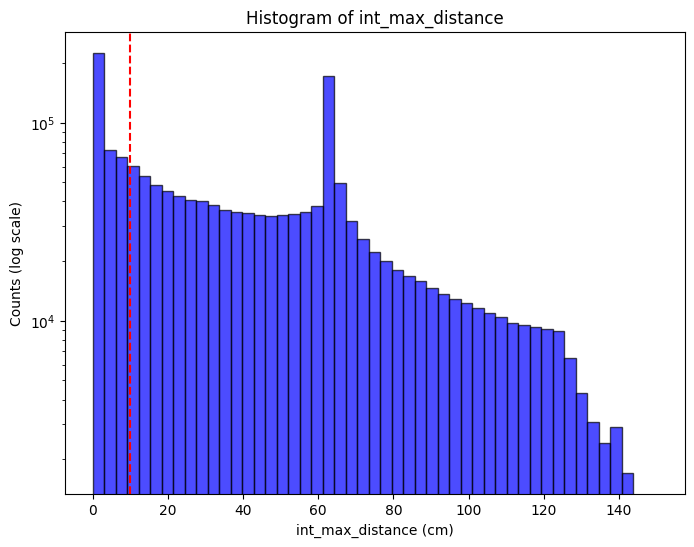

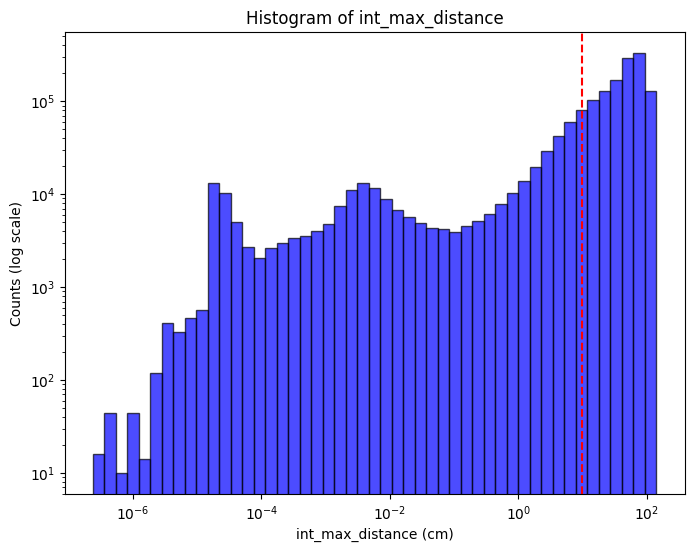

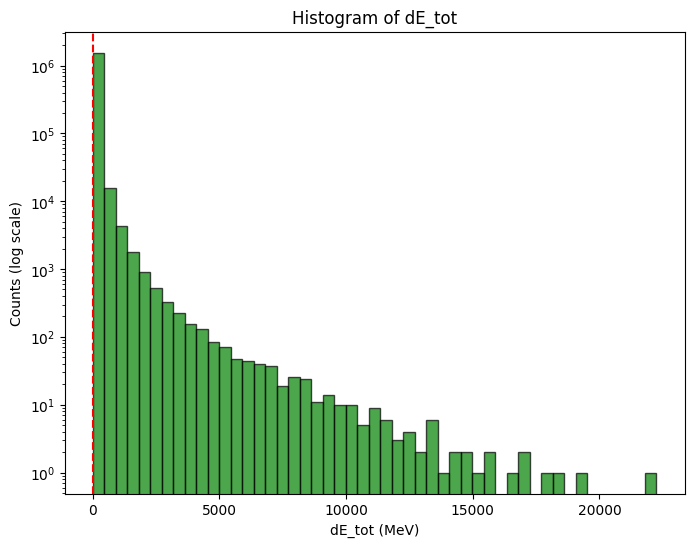

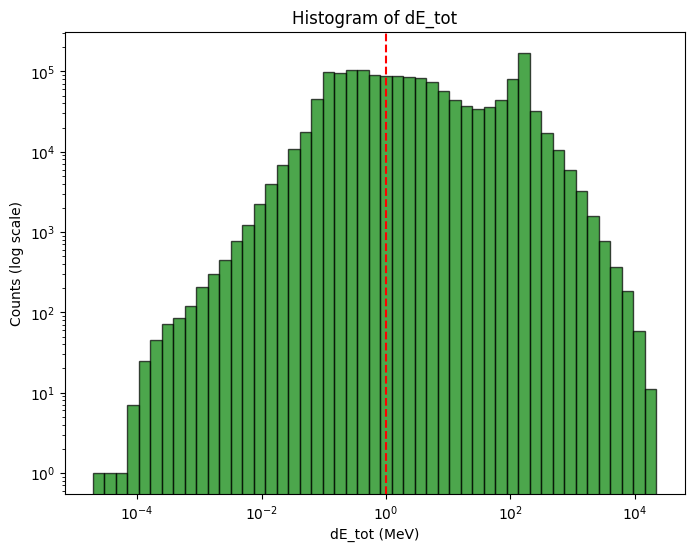

In [4]:
# plot int_max_distance histogram
plt.figure(figsize=(8,6))
int_max_bins = np.linspace(0, 150, 50)
plt.hist(df_truth_reco['int_max_distance'], bins=int_max_bins, alpha=0.7, color='blue', edgecolor='black', log=True)
# vertical line at 10cm
plt.axvline(x=10, color='red', linestyle='--', label='10 cm threshold')
plt.title('Histogram of int_max_distance')
plt.xlabel('int_max_distance (cm)')
plt.ylabel('Counts (log scale)')
plt.show()

# plot int_max_distance histogram
plt.figure(figsize=(8,6))
int_max_log_bins = np.logspace(np.min(np.log10(df_truth_reco['int_max_distance'][df_truth_reco['int_max_distance']>0])), np.log10(np.max(df_truth_reco['int_max_distance'])), 50)
plt.hist(df_truth_reco['int_max_distance'], bins=int_max_log_bins, alpha=0.7, color='blue', edgecolor='black', log=True)
# vertical line at 10cm
plt.axvline(x=10, color='red', linestyle='--', label='10 cm threshold')
plt.title('Histogram of int_max_distance')
plt.xlabel('int_max_distance (cm)')
plt.ylabel('Counts (log scale)')
plt.xscale('log')
plt.show()

# plot dE_tot histogram
plt.figure(figsize=(8,6))
dE_bins = np.linspace(0, np.max(df_truth_reco['dE_tot']), 50)
plt.hist(df_truth_reco['dE_tot'], bins=dE_bins, alpha=0.7, color='green', edgecolor='black', log=True)
# vertical line at 1 MeV
plt.axvline(x=1, color='red', linestyle='--', label='1 MeV threshold')
plt.title('Histogram of dE_tot')
plt.xlabel('dE_tot (MeV)')
plt.ylabel('Counts (log scale)')
plt.show()

# plot dE_tot histogram
plt.figure(figsize=(8,6))
dE_log_bins = np.logspace(np.min(np.log10(df_truth_reco['dE_tot'][df_truth_reco['dE_tot']>0])), np.log10(np.max(df_truth_reco['dE_tot'])), 50)
plt.hist(df_truth_reco['dE_tot'], bins=dE_log_bins, alpha=0.7, color='green', edgecolor='black', log=True)
# vertical line at 1 MeV
plt.axvline(x=1, color='red', linestyle='--', label='1 MeV threshold')
plt.title('Histogram of dE_tot')
plt.xlabel('dE_tot (MeV)')
plt.ylabel('Counts (log scale)')
plt.xscale('log')
plt.show()

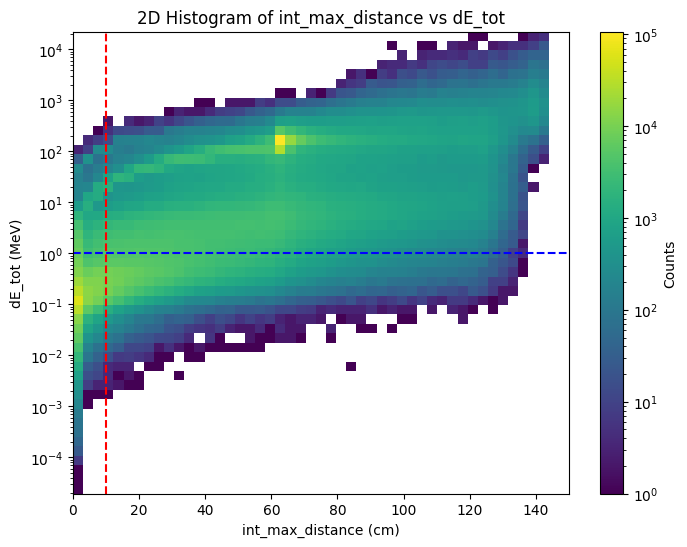

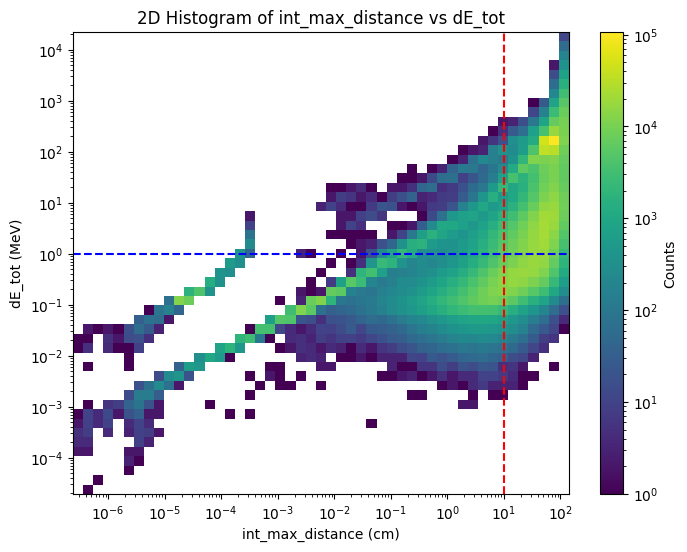

In [5]:
# 2d histogram  of int_max_distance (linear) vs dE_tot (log)
plt.figure(figsize=(8,6))
plt.hist2d(
    df_truth_reco['int_max_distance'],
    df_truth_reco['dE_tot'],
    bins=[int_max_bins, dE_log_bins],
    norm=LogNorm()
)
plt.colorbar(label='Counts')
plt.axvline(10, color='red', linestyle='--', label='10 cm threshold')
plt.axhline(1, color='blue', linestyle='--', label='1 MeV threshold')
plt.title('2D Histogram of int_max_distance vs dE_tot')
plt.xlabel('int_max_distance (cm)')
plt.ylabel('dE_tot (MeV)')
plt.yscale('log')
plt.show()


# histogram  of int_max_distance (log) vs dE_tot (log)
plt.figure(figsize=(8,6))
plt.hist2d(
    df_truth_reco['int_max_distance'],
    df_truth_reco['dE_tot'],
    bins=[int_max_log_bins, dE_log_bins],
    norm=LogNorm()
)
plt.colorbar(label='Counts')
plt.axvline(10, color='red', linestyle='--', label='10 cm threshold')
plt.axhline(1, color='blue', linestyle='--', label='1 MeV threshold')
plt.title('2D Histogram of int_max_distance vs dE_tot')
plt.xlabel('int_max_distance (cm)')
plt.ylabel('dE_tot (MeV)')
plt.xscale('log')
plt.yscale('log')
plt.show()


In [6]:
# for int max distance less than 10cm
df_truth_reco = df_truth_reco[df_truth_reco['int_max_distance'] < 10]

In [7]:
bit16 = 2**16 - 1
# use integer division so the 'num' argument to linspace is an int
wvfm_samples = np.linspace(-bit16//2, bit16//2, bit16)
# print first and last samples
print(wvfm_samples[0], wvfm_samples[-1])

wvfm_test1 = (wvfm_samples - wvfm_samples % 4).astype(float)
print(wvfm_test1[0], wvfm_test1[-1])

# interpret samples as signed 16-bit ints, then right-shift and convert back to float
wvfm_test2 = (wvfm_samples.astype(np.int16) >> 2).astype(float)
print(wvfm_test2[0], wvfm_test2[-1])

-32768.0 32767.0
-32768.0 32764.0
-8192.0 8191.0


In [8]:
tpc_bounds_cm = []
with h5py.File('/global/cfs/cdirs/dune/www/data/2x2/simulation/productions/MiniRun6.5_1E19_RHC/MiniRun6.5_1E19_RHC.flow/FLOW/0000000/MiniRun6.5_1E19_RHC.flow.0000000.FLOW.hdf5', 'r') as f:
    n_events = f['light/wvfm/data']['samples'].shape[0]
    mod_bounds_cm = np.array(f['geometry_info'].attrs['module_RO_bounds'])
    max_drift_distance = f['geometry_info'].attrs['max_drift_distance']
    for mod in mod_bounds_cm:
        x_min, x_max = mod[0][0], mod[1][0]
        y_min, y_max = mod[0][1], mod[1][1]
        z_min, z_max = mod[0][2], mod[1][2]
        x_min_adj = x_max - max_drift_distance
        x_max_adj = x_min + max_drift_distance
        tpc_bounds_cm.append(((x_min_adj, y_min, z_min), (x_max, y_max, z_max)))
        tpc_bounds_cm.append(((x_min, y_min, z_min), (x_max_adj, y_max, z_max)))
    tpc_bounds_cm = np.array(tpc_bounds_cm)
del f

# x-bounds: get unique first elements of each bound
tpc_bounds_rounded = tpc_bounds_cm #np.round(tpc_bounds_cm).astype(int)
x_bounds = [tuple(b) for b in tpc_bounds_rounded[:, :, 0]]
y_bounds = [tuple(b) for b in tpc_bounds_rounded[:, :, 1]]
z_bounds = [tuple(b) for b in tpc_bounds_rounded[:, :, 2]]

for i, xb in enumerate(x_bounds):
    print(f'TPC {i} X bounds (cm): {xb}')
for i, yb in enumerate(y_bounds):
    print(f'TPC {i} Y bounds (cm): {yb}')
for i, zb in enumerate(z_bounds):
    print(f'TPC {i} Z bounds (cm): {zb}')


TPC 0 X bounds (cm): (np.float64(33.65875219726563), np.float64(64.08975219726562))
TPC 1 X bounds (cm): (np.float64(2.910249948501587), np.float64(33.341249948501584))
TPC 2 X bounds (cm): (np.float64(33.65875219726563), np.float64(64.08975219726562))
TPC 3 X bounds (cm): (np.float64(2.910249948501587), np.float64(33.341249948501584))
TPC 4 X bounds (cm): (np.float64(-33.341249948501584), np.float64(-2.910249948501587))
TPC 5 X bounds (cm): (np.float64(-64.08975219726562), np.float64(-33.65875219726563))
TPC 6 X bounds (cm): (np.float64(-33.341249948501584), np.float64(-2.910249948501587))
TPC 7 X bounds (cm): (np.float64(-64.08975219726562), np.float64(-33.65875219726563))
TPC 0 Y bounds (cm): (np.float64(-62.07600021362305), np.float64(62.07600021362305))
TPC 1 Y bounds (cm): (np.float64(-62.07600021362305), np.float64(62.07600021362305))
TPC 2 Y bounds (cm): (np.float64(-62.07600021362305), np.float64(62.07600021362305))
TPC 3 Y bounds (cm): (np.float64(-62.07600021362305), np.floa

In [9]:
import scipy.stats as st
from scipy.stats import beta

def clopper_pearson_interval_numpy(k, n, alpha=0.05):
    """
    Vectorized Clopper-Pearson confidence interval for binomial proportions.

    Parameters:
    k : array-like
        Number of successes (can be an array).
    n : array-like
        Number of trials (can be an array).
    alpha : float, optional
        Significance level, default is 0.05 for a 95% confidence interval.

    Returns:
    ci_lower : ndarray
        Lower bound of the confidence interval.
    ci_upper : ndarray
        Upper bound of the confidence interval.
    """
    k = np.asarray(k, dtype=np.int64)
    n = np.asarray(n, dtype=np.int64)

    # Ensure valid values
    if np.any(k > n):
        raise ValueError("Number of successes k cannot be greater than number of trials n")

    alpha_2 = alpha / 2

    # Compute lower bound
    ci_lower = np.where(
        k > 0,
        st.beta.ppf(alpha_2, k, n - k + 1),
        0.0  # If k == 0, lower bound is 0
    )
    #ci_lower -= k/n

    # Compute upper bound
    ci_upper = np.where(
        k < n,
        st.beta.ppf(1 - alpha_2, k + 1, n - k),
        1.0  # If k == n, upper bound is 1
    )
    #ci_upper -= k/n

    return ci_lower, ci_upper

In [10]:
# define tolerance for causal link between interaction and reco hit
tol_idx = 10 # bins
tol_us = tol_idx * 16 / 1000

dE_tot_th = 1.0  # MeV

In [11]:
df_truth_1MeV = df_truth_reco[df_truth_reco['dE_tot'] >= dE_tot_th].copy()
df_truth_reco_1int = df_truth_1MeV[df_truth_1MeV['n_int_per_tpc'] == 1].copy()
df_truth_reco_1int_unique = df_truth_reco_1int.drop_duplicates(subset=['file_id', 'event_id', 'vertex_id', 'tpc_num'])
df_truth_reco_1int_unique_mod123 = df_truth_reco_1int_unique[df_truth_reco_1int_unique['tpc_num'] > 1]

df_truth_reco = df_truth_reco_1int_unique #_mod123

In [12]:
# map of det indices to trap type, one 0 then three 1s
det_to_trap_type = [(i % 4 != 0) for i in range(16)]
print(f"det_to_trap_type: {det_to_trap_type}")

# add column for any det_#_max > 1
det_max_cols = [f'det_{i}_max' for i in range(16)]

# mask for acls
acl_max_cols = [col for col, trap_type in zip(det_max_cols, det_to_trap_type) if not trap_type]
df_truth_reco['any_acl'] = (df_truth_reco[acl_max_cols].max(axis=1) > threshold_acl).astype(int)
print(f"acl_max_cols: {acl_max_cols}")

# mask for lcms
lcms_max_cols = [col for col, trap_type in zip(det_max_cols, det_to_trap_type) if trap_type]
df_truth_reco['any_lcm'] = (df_truth_reco[lcms_max_cols].max(axis=1) > threshold_lcm).astype(int)
print(f"lcms_max_cols: {lcms_max_cols}")

# combinded, for any_det == (any_acl or any_lcm)
df_truth_reco['any_det'] = ((df_truth_reco['any_acl'] == 1) | (df_truth_reco['any_lcm'] == 1)).astype(int)

# print number of events with any_det == 1 (and fraction)
print(f"Number of events with any_det == 1: {df_truth_reco['any_det'].sum()}")
print(f"Fraction of events with any_det == 1: {df_truth_reco['any_det'].mean()}")

det_to_trap_type: [False, True, True, True, False, True, True, True, False, True, True, True, False, True, True, True]
acl_max_cols: ['det_0_max', 'det_4_max', 'det_8_max', 'det_12_max']
lcms_max_cols: ['det_1_max', 'det_2_max', 'det_3_max', 'det_5_max', 'det_6_max', 'det_7_max', 'det_9_max', 'det_10_max', 'det_11_max', 'det_13_max', 'det_14_max', 'det_15_max']
Number of events with any_det == 1: 17769
Fraction of events with any_det == 1: 0.9554766897886756


In [13]:
# all interactions
all_true = df_truth_reco[df_truth_reco['vertex_id'].notna()]

det_rec = df_truth_reco[df_truth_reco['any_det'] == 1]
det_true_rec = df_truth_reco[(df_truth_reco['any_det'] == 1) & (df_truth_reco['vertex_id'].notna())]

acl_rec = df_truth_reco[df_truth_reco['any_acl'] == 1]
acl_true_rec = df_truth_reco[(df_truth_reco['any_acl'] == 1) & (df_truth_reco['vertex_id'].notna())]

lcm_rec = df_truth_reco[df_truth_reco['any_lcm'] == 1]
lcm_true_rec = df_truth_reco[(df_truth_reco['any_lcm'] == 1) & (df_truth_reco['vertex_id'].notna())]

# 1 interaction
all_true_1int = all_true[all_true['n_int_per_tpc'] == 1].copy()
df_truth_reco_1int = df_truth_reco[df_truth_reco['n_int_per_tpc'] == 1].copy()

det_rec_1int = df_truth_reco_1int[df_truth_reco_1int['any_det'] == 1]
det_true_rec_1int = df_truth_reco_1int[(df_truth_reco_1int['any_det'] == 1) & (df_truth_reco_1int['vertex_id'].notna())]

acl_rec_1int = df_truth_reco_1int[df_truth_reco_1int['any_acl'] == 1]
acl_true_rec_1int = df_truth_reco_1int[(df_truth_reco_1int['any_acl'] == 1) & (df_truth_reco_1int['vertex_id'].notna())]

lcm_rec_1int = df_truth_reco_1int[df_truth_reco_1int['any_lcm'] == 1]
lcm_true_rec_1int = df_truth_reco_1int[(df_truth_reco_1int['any_lcm'] == 1) & (df_truth_reco_1int['vertex_id'].notna())]

# 2 interactions
all_true_2int = all_true[all_true['n_int_per_tpc'] == 2].copy()
df_truth_reco_2int = df_truth_reco[df_truth_reco['n_int_per_tpc'] == 2].copy()

det_rec_2int = df_truth_reco_2int[df_truth_reco_2int['any_det'] == 1]
det_true_rec_2int = df_truth_reco_2int[(df_truth_reco_2int['any_det'] == 1) & (df_truth_reco_2int['vertex_id'].notna())]

acl_rec_2int = df_truth_reco_2int[df_truth_reco_2int['any_acl'] == 1]
acl_true_rec_2int = df_truth_reco_2int[(df_truth_reco_2int['any_acl'] == 1) & (df_truth_reco_2int['vertex_id'].notna())]

In [14]:
# overall efficiencies

# det efficiency
det_eff = len(det_true_rec) / len(all_true)
det_eff_cp_int = clopper_pearson_interval_numpy(len(det_true_rec), len(all_true), 0.05)
print(f"Det efficiency: {det_eff:.2f} ({det_eff_cp_int[0]:.2f}, {det_eff_cp_int[1]:.2f})")

# acl efficiency
acl_eff = len(acl_true_rec) / len(all_true)
acl_eff_cp_int = clopper_pearson_interval_numpy(len(acl_true_rec), len(all_true), 0.05)
print(f"ACL efficiency: {acl_eff:.2f} ({acl_eff_cp_int[0]:.2f}, {acl_eff_cp_int[1]:.2f})")

# lcm efficiency
lcm_eff = len(lcm_true_rec) / len(all_true)
lcm_eff_cp_int = clopper_pearson_interval_numpy(len(lcm_true_rec), len(all_true), 0.05)
print(f"LCM efficiency: {lcm_eff:.2f} ({lcm_eff_cp_int[0]:.2f}, {lcm_eff_cp_int[1]:.2f})")

# det fake rate
det_fake = 1 - (len(det_true_rec) / len(det_rec))
det_fake_cp_int = clopper_pearson_interval_numpy(len(det_rec) - len(det_true_rec), len(det_rec), 0.05)
print(f"Det fake rate: {det_fake:.2f} ({det_fake_cp_int[0]:.2f}, {det_fake_cp_int[1]:.2f})")

# acl fake rate
acl_fake = 1 - (len(acl_true_rec) / len(acl_rec))
acl_fake_cp_int = clopper_pearson_interval_numpy(len(acl_rec) - len(acl_true_rec), len(acl_rec), 0.05)
print(f"ACL fake rate: {acl_fake:.2f} ({acl_fake_cp_int[0]:.2f}, {acl_fake_cp_int[1]:.2f})")

# lcm fake rate
lcm_fake = 1 - (len(lcm_true_rec) / len(lcm_rec))
lcm_fake_cp_int = clopper_pearson_interval_numpy(len(lcm_rec) - len(lcm_true_rec), len(lcm_rec), 0.05)
print(f"LCM fake rate: {lcm_fake:.2f} ({lcm_fake_cp_int[0]:.2f}, {lcm_fake_cp_int[1]:.2f})")

Det efficiency: 0.96 (0.95, 0.96)
ACL efficiency: 0.57 (0.56, 0.58)
LCM efficiency: 0.87 (0.87, 0.88)
Det fake rate: 0.00 (0.00, 0.00)
ACL fake rate: 0.00 (0.00, 0.00)
LCM fake rate: 0.00 (0.00, 0.00)


In [15]:
'''
# loop over dE_tot threshholds and calculate efficiency and plot for Det, ACL, LCM
dE_tot_threshholds = np.arange(0.1, 1.1, 0.1)  # MeV
det_effs = []
acl_effs = []
lcm_effs = []
for dE_tot_th in dE_tot_threshholds:
    df_truth_1MeV = df_truth_reco[df_truth_reco['dE_tot'] >= dE_tot_th].copy()
    df_truth_reco_1int = df_truth_1MeV[df_truth_1MeV['n_int_per_tpc'] == 1].copy()
    df_truth_reco_1int_unique = df_truth_reco_1int.drop_duplicates(subset=['file_id', 'event_id', 'vertex_id', 'tpc_num'])
    df_truth_reco = df_truth_reco_1int_unique

    all_true = df_truth_reco[df_truth_reco['vertex_id'].notna()]

    det_rec = df_truth_reco[df_truth_reco['any_det'] == 1]
    det_true_rec = df_truth_reco[(df_truth_reco['any_det'] == 1) & (df_truth_reco['vertex_id'].notna())]

    acl_rec = df_truth_reco[df_truth_reco['any_acl'] == 1]
    acl_true_rec = df_truth_reco[(df_truth_reco['any_acl'] == 1) & (df_truth_reco['vertex_id'].notna())]

    lcm_rec = df_truth_reco[df_truth_reco['any_lcm'] == 1]
    lcm_true_rec = df_truth_reco[(df_truth_reco['any_lcm'] == 1) & (df_truth_reco['vertex_id'].notna())]

    # det efficiency
    det_eff = len(det_true_rec) / len(all_true)
    det_eff_cp_int = clopper_pearson_interval_numpy(len(det_true_rec), len(all_true), 0.05)
    print(f"dE_tot_th: {dE_tot_th:.2f} MeV - Det efficiency: {det_eff:.2f} ({det_eff_cp_int[0]:.2f}, {det_eff_cp_int[1]:.2f})")

    # acl efficiency
    acl_eff = len(acl_true_rec) / len(all_true)
    acl_eff_cp_int = clopper_pearson_interval_numpy(len(acl_true_rec), len(all_true), 0.05)
    print(f"dE_tot_th: {dE_tot_th:.2f} MeV - ACL efficiency: {acl_eff:.2f} ({acl_eff_cp_int[0]:.2f}, {acl_eff_cp_int[1]:.2})")

    # lcm efficiency
    lcm_eff = len(lcm_true_rec) / len(all_true)
    lcm_eff_cp_int = clopper_pearson_interval_numpy(len(lcm_true_rec), len(all_true), 0.05)
    print(f"dE_tot_th: {dE_tot_th:.2f} MeV - LCM efficiency: {lcm_eff:.2f} ({lcm_eff_cp_int[0]:.2f}, {lcm_eff_cp_int[1]:.2f})")

    det_effs.append(det_eff)
    acl_effs.append(acl_eff)
    lcm_effs.append(lcm_eff)

# plot efficiencies vs dE_tot_threshholds
plt.figure(figsize=(8,6))
# use step for central line and fill betweeen for uncertainty
plt.step(dE_tot_threshholds, det_effs, where='pre', label='Det Efficiency', color='blue')
plt.fill_between(dE_tot_threshholds,
                 [clopper_pearson_interval_numpy(int(eff * len(all_true)), len(all_true), 0.05)[0] for eff in det_effs],
                 [clopper_pearson_interval_numpy(int(eff * len(all_true)), len(all_true), 0.05)[1] for eff in det_effs],
                 step='pre', color='blue', alpha=0.3)
plt.step(dE_tot_threshholds, acl_effs, where='pre', label='ACL Efficiency', color='green')
plt.fill_between(dE_tot_threshholds,
                 [clopper_pearson_interval_numpy(int(eff * len(all_true)), len(all_true), 0.05)[0] for eff in acl_effs],
                 [clopper_pearson_interval_numpy(int(eff * len(all_true)), len(all_true), 0.05)[1] for eff in acl_effs],
                 step='pre', color='green', alpha=0.3)
plt.step(dE_tot_threshholds, lcm_effs, where='pre', label='LCM Efficiency', color='orange')
plt.fill_between(dE_tot_threshholds,
                 [clopper_pearson_interval_numpy(int(eff * len(all_true)), len(all_true), 0.05)[0] for eff in lcm_effs],
                 [clopper_pearson_interval_numpy(int(eff * len(all_true)), len(all_true), 0.05)[1] for eff in lcm_effs],
                 step='pre', color='orange', alpha=0.3)
plt.title('Efficiency vs dE_tot Threshold')
plt.xlabel('dE_tot Threshold (MeV)')
plt.ylabel('Efficiency')
plt.ylim(0, 1)
plt.legend()
plt.grid()
plt.show()
'''

'\n# loop over dE_tot threshholds and calculate efficiency and plot for Det, ACL, LCM\ndE_tot_threshholds = np.arange(0.1, 1.1, 0.1)  # MeV\ndet_effs = []\nacl_effs = []\nlcm_effs = []\nfor dE_tot_th in dE_tot_threshholds:\n    df_truth_1MeV = df_truth_reco[df_truth_reco[\'dE_tot\'] >= dE_tot_th].copy()\n    df_truth_reco_1int = df_truth_1MeV[df_truth_1MeV[\'n_int_per_tpc\'] == 1].copy()\n    df_truth_reco_1int_unique = df_truth_reco_1int.drop_duplicates(subset=[\'file_id\', \'event_id\', \'vertex_id\', \'tpc_num\'])\n    df_truth_reco = df_truth_reco_1int_unique\n\n    all_true = df_truth_reco[df_truth_reco[\'vertex_id\'].notna()]\n\n    det_rec = df_truth_reco[df_truth_reco[\'any_det\'] == 1]\n    det_true_rec = df_truth_reco[(df_truth_reco[\'any_det\'] == 1) & (df_truth_reco[\'vertex_id\'].notna())]\n\n    acl_rec = df_truth_reco[df_truth_reco[\'any_acl\'] == 1]\n    acl_true_rec = df_truth_reco[(df_truth_reco[\'any_acl\'] == 1) & (df_truth_reco[\'vertex_id\'].notna())]\n\n    lcm_r

In [16]:
# plot for comparing different hit types

def plot_histogram_ratio_with_error(df_A, df_B, legend, cols, bins, xlabel, ylabel,
                                    alpha=0.05, neg=False, yscale='linear', xscale='linear',
                                    drop_ratio=True):

    if len(df_A) != len(df_B):
        raise ValueError("df_A and df_B must have the same length")

    # Initialize the plot
    if len(df_A) > 1 and not drop_ratio:
        fig, axs = plt.subplots(2, 1, figsize=(6, 4), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)
        ax = axs[0]
    else:
        fig, ax = plt.subplots(figsize=(8, 4))

    # Iterate over the datasets
    frac_0 = None
    for i, (data_A, data_B) in enumerate(zip(df_A, df_B)):
        # Compute histograms
        hist_A, _ = np.histogram(data_A, bins=bins)
        hist_B, _ = np.histogram(data_B, bins=bins)

        # Compute bin centers
        bin_centers = (bins[:-1])

        # Compute ratio A/B
        frac = np.divide(hist_A, hist_B, out=np.zeros_like(hist_A, dtype=float), where=hist_B != 0)
        frac = 1 - frac if neg else frac

        # Store the first ratio for later use
        if i == 0:
            frac_0 = frac

        # Compute Clopper-Pearson intervals for ratio
        lower_bounds, upper_bounds = clopper_pearson_interval_numpy(hist_A, hist_B, alpha=alpha)
        if neg:
            lower_bounds = 1 - lower_bounds
            upper_bounds = 1 - upper_bounds

        # Plot the ratio with error bands
        ax.step(bin_centers, frac, alpha=0.8, label=legend[i], color=cols[i])
        ax.fill_between(bin_centers, lower_bounds, upper_bounds, step='pre', alpha=0.2, color=cols[i])

        # Plot the ratio of each entry to frac[0] if len(df_A) > 1 and drop_ratio is False
        if len(df_A) > 1 and not drop_ratio:
            axs[1].step(bin_centers, frac / frac_0, alpha=0.8, label=f"Ratio to {legend[0]}", color=cols[i])
            axs[1].fill_between(bin_centers, lower_bounds / frac_0, upper_bounds / frac_0, step='pre', alpha=0.2, color=cols[i])
            axs[1].set_ylabel('Ratio')
            axs[1].set_xlim(bins[0], bins[-2])
            axs[1].set_xlabel(xlabel)

    # Formatting
    ax.set_ylabel(ylabel)
    ax.set_yscale(yscale)
    ax.set_xscale(xscale)
    ax.set_xlim(bins[0], bins[-2])
    ax.legend()

    if len(df_A) <= 1 or drop_ratio:
        ax.set_xlabel(xlabel)

    plt.tight_layout()
    plt.show()


In [17]:
# Define nint histogram bins
all_true_nint = all_true['n_int_per_tpc'].dropna()
det_reco_nint = det_rec['n_int_per_tpc'].dropna()
det_true_reco_nint = det_true_rec['n_int_per_tpc'].dropna()

In [18]:
# x_mean, y_mean, z_mean
all_true_x = all_true['x_wmean_int'].dropna()
det_reco_x = det_rec['x_wmean_int'].dropna()
det_true_reco_x = det_true_rec['x_wmean_int'].dropna()
acl_reco_x = acl_rec['x_wmean_int'].dropna()
acl_true_reco_x = acl_true_rec['x_wmean_int'].dropna()
lcm_reco_x = lcm_rec['x_wmean_int'].dropna()
lcm_true_reco_x = lcm_true_rec['x_wmean_int'].dropna()

# y_mean
all_true_y = all_true['y_wmean_int'].dropna()
det_reco_y = det_rec['y_wmean_int'].dropna()
det_true_reco_y = det_true_rec['y_wmean_int'].dropna()
acl_reco_y = acl_rec['y_wmean_int'].dropna()
acl_true_reco_y = acl_true_rec['y_wmean_int'].dropna()
lcm_reco_y = lcm_rec['y_wmean_int'].dropna()
lcm_true_reco_y = lcm_true_rec['y_wmean_int'].dropna()

# z_mean
all_true_z = all_true['z_wmean_int'].dropna()
det_reco_z = det_rec['z_wmean_int'].dropna()
det_true_reco_z = det_true_rec['z_wmean_int'].dropna()
acl_reco_z = acl_rec['z_wmean_int'].dropna()
acl_true_reco_z = acl_true_rec['z_wmean_int'].dropna()
lcm_reco_z = lcm_rec['z_wmean_int'].dropna()
lcm_true_reco_z = lcm_true_rec['z_wmean_int'].dropna()

In [19]:
# Use subplots to include x, y, z next to one another for efficiency/fake-rate plots
def plot_histogram_ratio_with_error_side_by_side(
    df_A_list, df_B_list, legend, cols, bins, xlabel_list, ylabel, alpha=0.05,
    neg=False, yscale='linear', xscale='linear', hline=None, drop_ratio=True):

    def _get_bins(bins_param, idx):
        if isinstance(bins_param, (list, tuple)):
            return np.asarray(bins_param[idx])
        return np.asarray(bins_param)

    fig, axs = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
    xyz_labels = ['X', 'Y', 'Z']
    for idx, ax in enumerate(axs):
        df_A = df_A_list[idx]
        df_B = df_B_list[idx]
        bins_curr = _get_bins(bins, idx)
        for i, (data_A, data_B) in enumerate(zip(df_A, df_B)):
            hist_A, _ = np.histogram(data_A, bins=bins_curr)
            hist_B, _ = np.histogram(data_B, bins=bins_curr)
            bin_centers = bins_curr[:-1]
            frac = np.divide(hist_A, hist_B, out=np.full_like(hist_A, np.nan, dtype=float), where=hist_B != 0)
            frac = 1 - frac if neg else frac
            lower_bounds, upper_bounds = clopper_pearson_interval_numpy(hist_A, hist_B, alpha=alpha)
            if neg:
                lower_bounds = 1 - lower_bounds
                upper_bounds = 1 - upper_bounds
            frac[hist_B == 0] = np.nan
            lower_bounds[hist_B == 0] = np.nan
            upper_bounds[hist_B == 0] = np.nan
            ax.step(bin_centers, frac, alpha=0.8, label=legend[i], color=cols[i])
            ax.fill_between(bin_centers, lower_bounds, upper_bounds, step='pre', alpha=0.2, color=cols[i])
        ax.set_xlabel(xlabel_list[idx])
        ax.set_yscale(yscale)
        ax.set_xscale(xscale)
        ax.set_xlim(bins_curr[0], bins_curr[-2])
        ax.set_ylim(0, 1)
        if hline is not None:
            ax.axhline(y=hline, color='k', linestyle='--', label='no pileup')
        ax.set_title(f'{xyz_labels[idx]} Mean')
        if idx == 0:
            ax.set_ylabel(ylabel)
        ax.legend()
        if not neg:
            ax.set_ylim(0.0, 1.0)
        else:
            ax.set_ylim(0, 0.2)
    plt.tight_layout()
    plt.show()

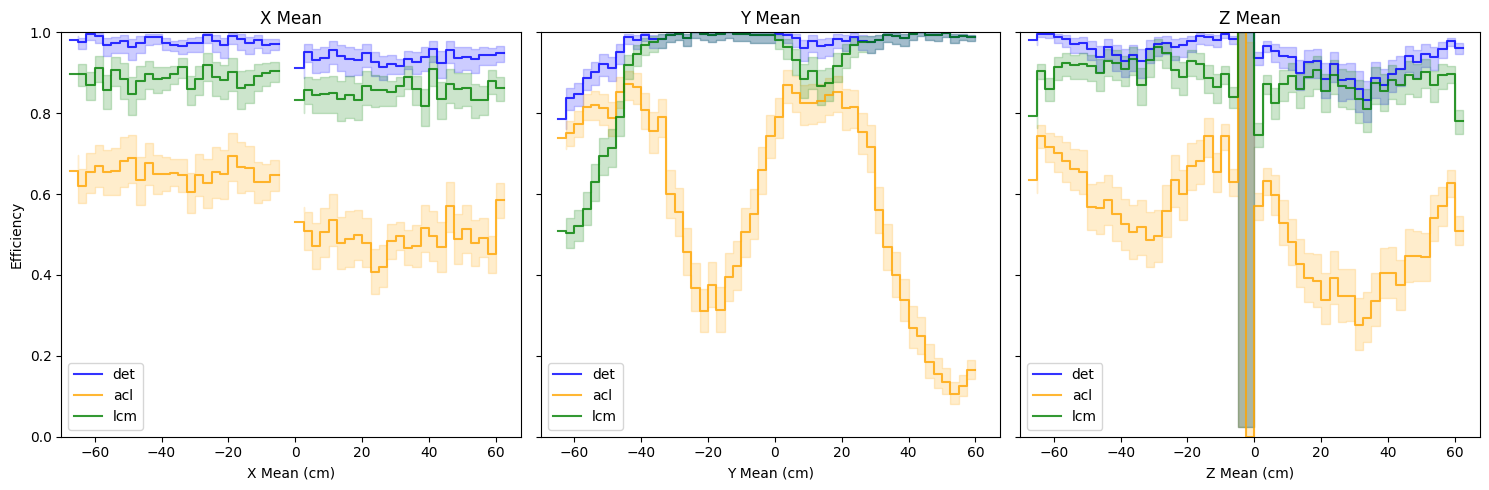

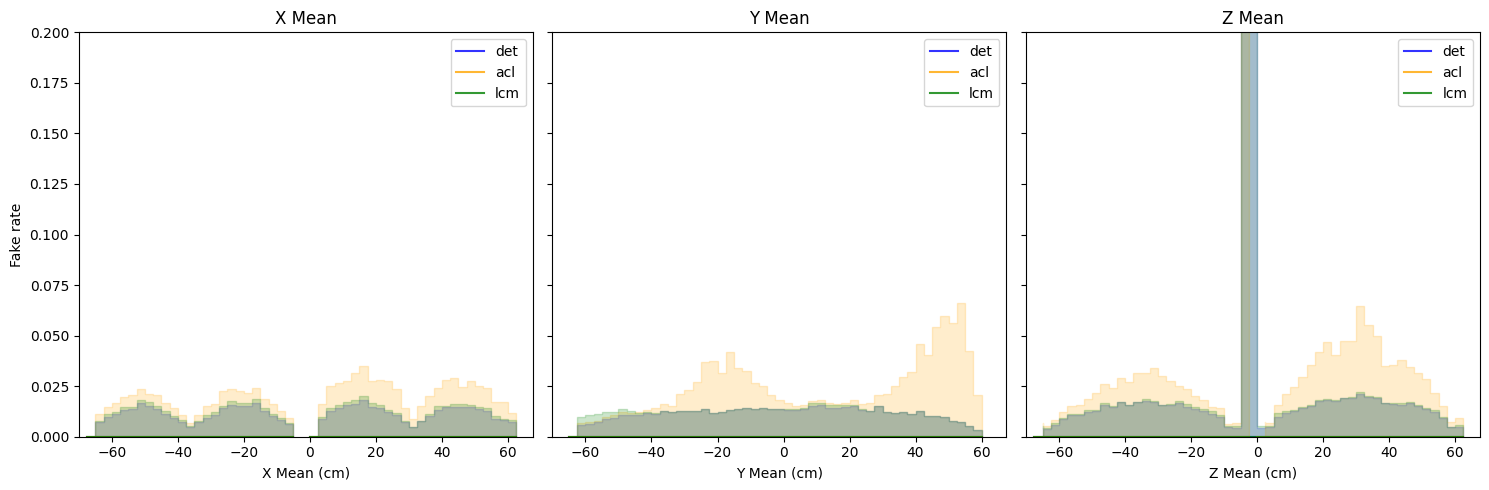

In [20]:
# Use subplots to include x, y, z next to one another for efficiency plots
plot_histogram_ratio_with_error_side_by_side(
    df_A_list=[
        [det_true_reco_x, acl_true_reco_x, lcm_true_reco_x],
        [det_true_reco_y, acl_true_reco_y, lcm_true_reco_y],
        [det_true_reco_z, acl_true_reco_z, lcm_true_reco_z]
    ],
    df_B_list=[
        [all_true_x, all_true_x, all_true_x],
        [all_true_y, all_true_y, all_true_y],
        [all_true_z, all_true_z, all_true_z]
    ],
    legend=['det', 'acl', 'lcm'],
    cols=['blue', 'orange', 'green'],
    bins=[xbins, ybins, zbins],
    xlabel_list=['X Mean (cm)', 'Y Mean (cm)', 'Z Mean (cm)'],
    ylabel='Efficiency'
)

# This doesnt look right! not sure why!
# repeat for fake rate
plot_histogram_ratio_with_error_side_by_side(
    df_A_list=[
        [det_true_reco_x, acl_true_reco_x, lcm_true_reco_x],
        [det_true_reco_y, acl_true_reco_y, lcm_true_reco_y],
        [det_true_reco_z, acl_true_reco_z, lcm_true_reco_z]
    ],
    df_B_list=[
        [det_reco_x, acl_reco_x, lcm_reco_x],
        [det_reco_y, acl_reco_y, lcm_reco_y],
        [det_reco_z, acl_reco_z, lcm_reco_z]
    ],
    legend=['det', 'acl', 'lcm'],
    cols=['blue', 'orange', 'green'],
    bins=[xbins, ybins, zbins],
    xlabel_list=['X Mean (cm)', 'Y Mean (cm)', 'Z Mean (cm)'],
    ylabel='Fake rate',
    neg=True
)

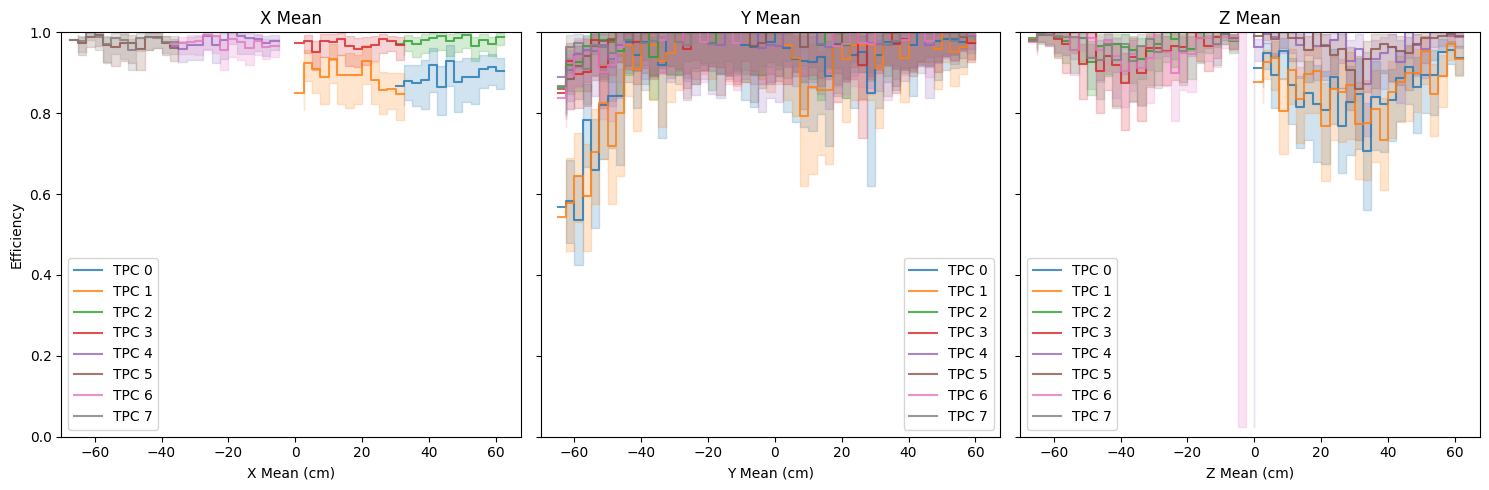

In [21]:
# plot all TPCs on the same axes (overlay by TPC)
tpcs = list(range(8))
legend = [f'TPC {t}' for t in tpcs]
cols = [plt.cm.tab10(i % 10) for i in range(len(tpcs))]

df_A_x, df_A_y, df_A_z = [], [], []
df_B_x, df_B_y, df_B_z = [], [], []

for tpc_num in tpcs:
  all_true_tpc = all_true[all_true['tpc_num'] == float(tpc_num)]
  det_true_rec_tpc = det_true_rec[det_true_rec['tpc_num'] == float(tpc_num)]

  df_A_x.append(det_true_rec_tpc['x_wmean_int'].dropna())
  df_B_x.append(all_true_tpc['x_wmean_int'].dropna())

  df_A_y.append(det_true_rec_tpc['y_wmean_int'].dropna())
  df_B_y.append(all_true_tpc['y_wmean_int'].dropna())

  df_A_z.append(det_true_rec_tpc['z_wmean_int'].dropna())
  df_B_z.append(all_true_tpc['z_wmean_int'].dropna())

plot_histogram_ratio_with_error_side_by_side(
  df_A_list=[df_A_x, df_A_y, df_A_z],
  df_B_list=[df_B_x, df_B_y, df_B_z],
  legend=legend,
  cols=cols,
  bins=[xbins, ybins, zbins],
  xlabel_list=['X Mean (cm)', 'Y Mean (cm)', 'Z Mean (cm)'],
  ylabel='Efficiency'
)


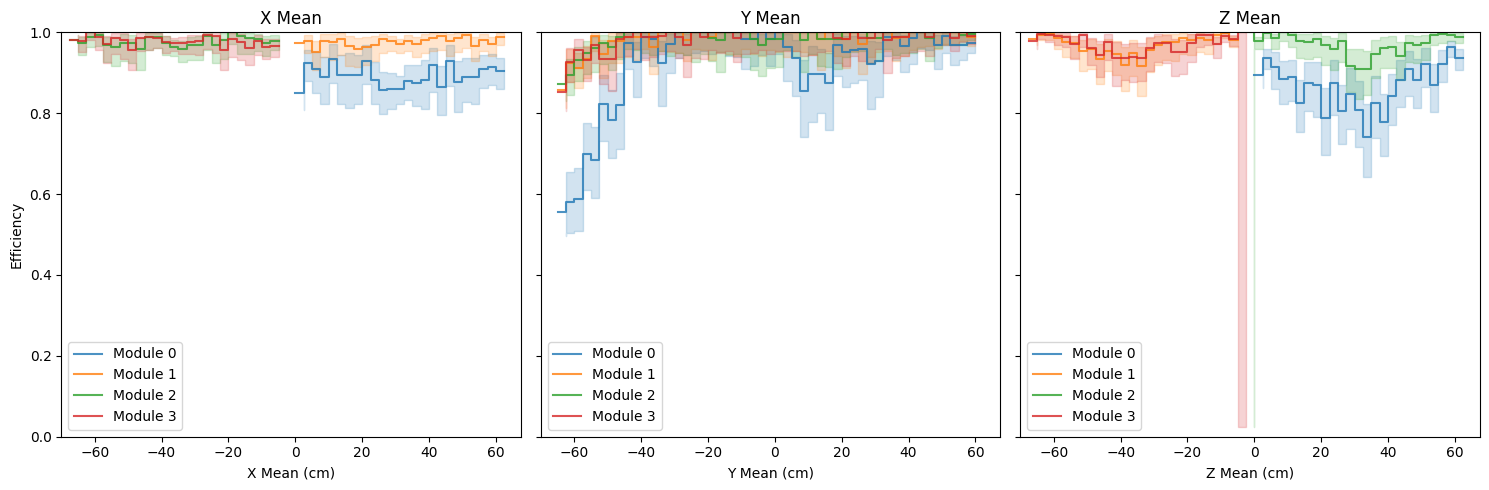

In [22]:
# plot all modules on the same axes (overlay by module)
# Each module consists of a pair of TPCs: (0,1), (2,3), (4,5), (6,7)
modules = [(0, 1), (2, 3), (4, 5), (6, 7)]
legend = [f'Module {i}' for i, m in enumerate(modules)]
cols = [plt.cm.tab10(i % 10) for i in range(len(modules))]

df_A_x, df_A_y, df_A_z = [], [], []
df_B_x, df_B_y, df_B_z = [], [], []

for tpc_pair in modules:
  # Combine data from both TPCs in the module
  all_true_mod = all_true[all_true['tpc_num'].isin([float(tpc_pair[0]), float(tpc_pair[1])])]
  det_true_rec_mod = det_true_rec[det_true_rec['tpc_num'].isin([float(tpc_pair[0]), float(tpc_pair[1])])]

  df_A_x.append(det_true_rec_mod['x_wmean_int'].dropna())
  df_B_x.append(all_true_mod['x_wmean_int'].dropna())

  df_A_y.append(det_true_rec_mod['y_wmean_int'].dropna())
  df_B_y.append(all_true_mod['y_wmean_int'].dropna())

  df_A_z.append(det_true_rec_mod['z_wmean_int'].dropna())
  df_B_z.append(all_true_mod['z_wmean_int'].dropna())

plot_histogram_ratio_with_error_side_by_side(
  df_A_list=[df_A_x, df_A_y, df_A_z],
  df_B_list=[df_B_x, df_B_y, df_B_z],
  legend=legend,
  cols=cols,
  bins=[xbins, ybins, zbins],
  xlabel_list=['X Mean (cm)', 'Y Mean (cm)', 'Z Mean (cm)'],
  ylabel='Efficiency'
)

In [23]:
# function for three 2D heatmaps of efficiency vs x-y, x-z, y-z
def plot_2d_efficiency_heatmaps(x_A, y_A, z_A, x_B, y_B, z_B,
                                bins_x, bins_y, bins_z,
                                xlabel_list, ylabel_list, clabel,
                                neg=False, bin_mask = None):
    fig, axs = plt.subplots(1, 3, figsize=(18, 5))

    def plot_panel(ax, a1, a2, b1, b2, bins1, bins2, xlabel, ylabel, title, panel_mask=None):
        hist_A, _, _ = np.histogram2d(a1, a2, bins=[bins1, bins2])
        hist_B, _, _ = np.histogram2d(b1, b2, bins=[bins1, bins2])
        eff = np.divide(hist_A, hist_B, out=np.zeros_like(hist_A, dtype=float), where=hist_B != 0)
        val = (1 - eff) if neg else eff
        if panel_mask is not None:
            val = np.where(panel_mask, np.nan, val)
        label = clabel
        cmap = plt.cm.get_cmap('viridis').copy()
        cmap.set_bad(color='white')
        im = ax.imshow(val.T,
                       origin='lower',
                       aspect='auto',
                       extent=[bins1[0], bins1[-1], bins2[0], bins2[-1]],
                       vmin=0, vmax=1,
                       cmap=cmap)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        fig.colorbar(im, ax=ax, label=label)

    def select_mask(mask, shape, idx):
        if mask is None:
            return None
        if isinstance(mask, dict):
            key = ['xy', 'xz', 'yz'][idx]
            m = mask.get(key, None)
        elif isinstance(mask, (list, tuple)):
            m = mask[idx] if len(mask) == 3 else mask[0]
        else:
            m = mask
        if m is None:
            return None
        m_arr = np.asarray(m)
        if m_arr.shape != shape:
            raise ValueError(f'bin_mask shape {m_arr.shape} does not match panel shape {shape}')
        return m_arr.astype(bool)

    shape_xy = (len(bins_x)-1, len(bins_y)-1)
    shape_xz = (len(bins_x)-1, len(bins_z)-1)
    shape_yz = (len(bins_z)-1, len(bins_y)-1)

    mask_xy = select_mask(bin_mask, shape_xy, 0)
    mask_xz = select_mask(bin_mask, shape_xz, 1)
    mask_yz = select_mask(bin_mask, shape_yz, 2)

    plot_panel(axs[0], x_A, y_A, x_B, y_B, bins_x, bins_y, xlabel_list[0], ylabel_list[0], 'X-Y Mean', mask_xy)
    plot_panel(axs[1], x_A, z_A, x_B, z_B, bins_x, bins_z, xlabel_list[1], ylabel_list[1], 'X-Z Mean', mask_xz)
    plot_panel(axs[2], z_A, y_A, z_B, y_B, bins_z, bins_y, xlabel_list[2], ylabel_list[2], 'Y-Z Mean', mask_yz)

    plt.tight_layout()
    plt.show()


/tmp/ipykernel_1682501/361697591.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis').copy()


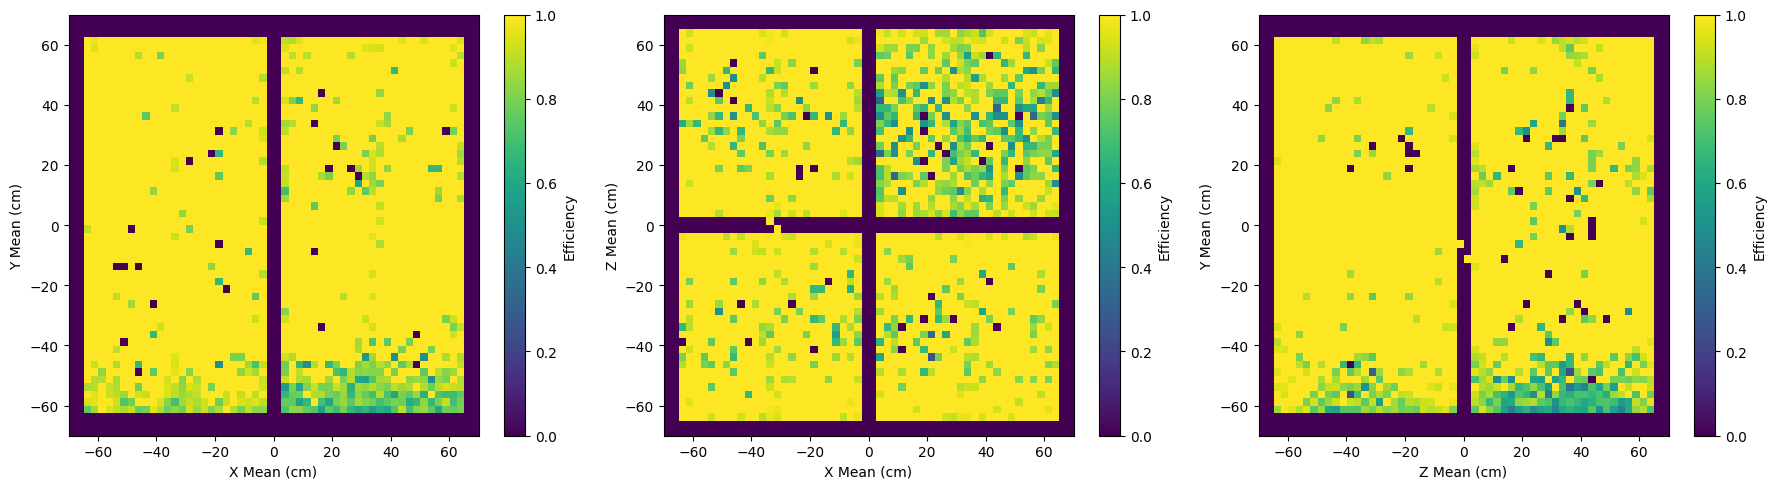

In [24]:
bins = np.linspace(-70, 70, 140)
plot_2d_efficiency_heatmaps(
    x_A=det_true_reco_x,
    y_A=det_true_reco_y,
    z_A=det_true_reco_z,
    x_B=all_true_x,
    y_B=all_true_y,
    z_B=all_true_z,
    bins_x=xbins,
    bins_y=ybins,
    bins_z=zbins,
    xlabel_list=['X Mean (cm)', 'X Mean (cm)', 'Z Mean (cm)'],
    ylabel_list=['Y Mean (cm)', 'Z Mean (cm)', 'Y Mean (cm)'],
    clabel='Efficiency'
)

/tmp/ipykernel_1682501/361697591.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis').copy()


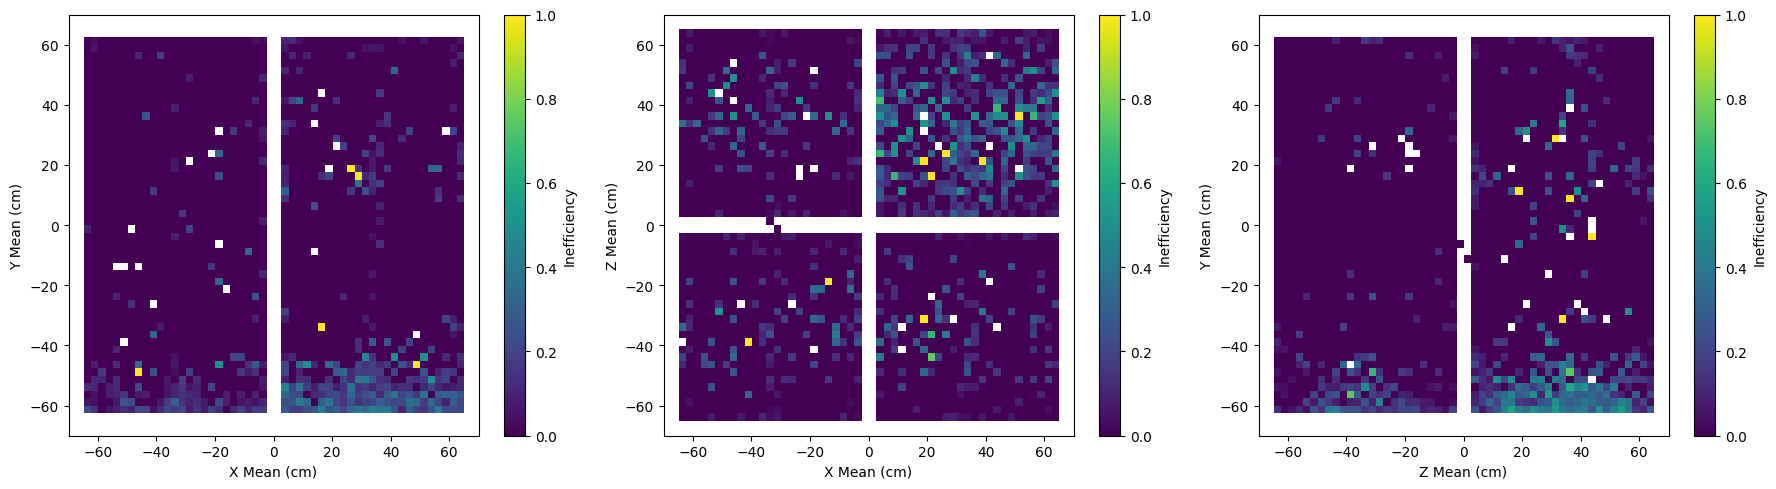

In [25]:
# bin mask for bins where all_true_x, all_true_y, all_true_z are empty
bin_mask = {
    'xy': np.zeros((len(xbins)-1, len(xbins)-1), dtype=bool),
    'xz': np.zeros((len(ybins)-1, len(ybins)-1), dtype=bool),
    'zy': np.zeros((len(zbins)-1, len(zbins)-1), dtype=bool)
}
# fill in bin_mask
hist_all_xy, xedges, yedges = np.histogram2d(all_true_x, all_true_y, bins=[xbins, ybins])
hist_all_xz, xedges, zedges = np.histogram2d(all_true_x, all_true_z, bins=[xbins, zbins])
hist_all_zy, zedges, yedges = np.histogram2d(all_true_z, all_true_y, bins=[zbins, ybins])
bin_mask['xy'] = hist_all_xy == 0
bin_mask['xz'] = hist_all_xz == 0
bin_mask['zy'] = hist_all_zy == 0

plot_2d_efficiency_heatmaps(
    x_A=det_true_reco_x,
    y_A=det_true_reco_y,
    z_A=det_true_reco_z,
    x_B=all_true_x,
    y_B=all_true_y,
    z_B=all_true_z,
    bins_x=xbins,
    bins_y=ybins,
    bins_z=zbins,
    xlabel_list=['X Mean (cm)', 'X Mean (cm)', 'Z Mean (cm)'],
    ylabel_list=['Y Mean (cm)', 'Z Mean (cm)', 'Y Mean (cm)'],
    neg=True,
    bin_mask=[bin_mask['xy'], bin_mask['xz'], bin_mask['zy']],
    clabel='Inefficiency'
)

In [26]:
# take the x,y,z binning and make 3D voxels, calculate efficiency in each voxel, and plot 2D slices (akin to plot_2d_efficiency_heatmaps) but animating through the 3D efficiency map
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from matplotlib.animation import FuncAnimation, PillowWriter

def plot_3d_efficiency_slices(x_A, y_A, z_A, x_B, y_B, z_B,
                              bins_x, bins_y, bins_z,
                              xlabel_list, ylabel_list, clabel,
                              neg=False, slice_axis='z', interval=200,
                              bin_mask=None, save_gif=None, fps=10):
    """
    Make animated 2D slices through a 3D efficiency map.

    bin_mask:
        Boolean array with shape (len(bins_x)-1, len(bins_y)-1, len(bins_z)-1)
        where True means "mask this voxel" (set to NaN in the plot).
        If None, no masking is applied.
    """

    # --- 3D histograms ---
    hist_A, edges = np.histogramdd(
        np.vstack((x_A, y_A, z_A)).T,
        bins=[bins_x, bins_y, bins_z]
    )
    edges_x, edges_y, edges_z = edges

    hist_B, _ = np.histogramdd(
        np.vstack((x_B, y_B, z_B)).T,
        bins=[bins_x, bins_y, bins_z]
    )

    eff_3d = np.divide(
        hist_A,
        hist_B,
        out=np.zeros_like(hist_A, dtype=float),
        where=hist_B != 0
    )
    val_3d = (1 - eff_3d) if neg else eff_3d

    # --- apply 3D mask if provided ---
    if bin_mask is not None:
        m_arr = np.asarray(bin_mask)
        expected_shape = val_3d.shape
        if m_arr.shape != expected_shape:
            raise ValueError(
                f"bin_mask shape {m_arr.shape} does not match 3D bin shape {expected_shape}"
            )
        m_arr = m_arr.astype(bool)
        val_3d = np.where(m_arr, np.nan, val_3d)

    fig, ax = plt.subplots(figsize=(6, 5))

    # --- helper to pull a slice along the chosen axis ---
    def get_slice(slice_idx):
        if slice_axis == 'z':
            # X-Y plane: x horizontal, y vertical
            slice_data = val_3d[:, :, slice_idx].T  # transpose so y is vertical
            extent = [edges_x[0], edges_x[-1], edges_y[0], edges_y[-1]]
            xlabel = xlabel_list[0]  # e.g. 'X Mean (cm)'
            ylabel = ylabel_list[0]  # e.g. 'Y Mean (cm)'
        elif slice_axis == 'y':
            # X-Z plane: x horizontal, z vertical
            slice_data = val_3d[:, slice_idx, :].T  # transpose so z is vertical
            extent = [edges_x[0], edges_x[-1], edges_z[0], edges_z[-1]]
            xlabel = xlabel_list[1]  # e.g. 'X Mean (cm)'
            ylabel = ylabel_list[1]  # e.g. 'Z Mean (cm)'
        elif slice_axis == 'x':
            # Y-Z plane: y horizontal, z vertical
            slice_data = val_3d[slice_idx, :, :]  # transpose so z is vertical
            extent = [edges_z[0], edges_z[-1], edges_y[0], edges_y[-1]]
            xlabel = ylabel_list[2]  # e.g. 'Y Mean (cm)'
            ylabel = xlabel_list[2]  # e.g. 'Z Mean (cm)'
        else:
            raise ValueError("slice_axis must be 'x', 'y', or 'z'")
        return slice_data, extent, xlabel, ylabel

    # --- init with slice 0 ---
    slice0, extent, xlabel, ylabel = get_slice(0)

    cmap = plt.cm.get_cmap('viridis').copy()
    cmap.set_bad(color='white')

    im = ax.imshow(
        slice0,
        origin='lower',
        aspect='auto',
        extent=extent,
        vmin=0, vmax=1,
        cmap=cmap
    )
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    fig.colorbar(im, ax=ax, label=clabel)

    # first-slice bin range for title
    if slice_axis == 'z':
        low0, high0 = edges_z[0], edges_z[1]
    elif slice_axis == 'y':
        low0, high0 = edges_y[0], edges_y[1]
    else:  # 'x'
        low0, high0 = edges_x[0], edges_x[1]
    ax.set_title(f"{slice_axis.upper()} Slice 0 ({low0:.2f} to {high0:.2f})")
    plt.tight_layout()

    # --- update function for animation ---
    def update_slice(slice_idx):
        slice_data, _, _, _ = get_slice(slice_idx)

        # bin-range in physical units for this slice
        if slice_axis == 'z':
            low, high = edges_z[slice_idx], edges_z[slice_idx + 1]
        elif slice_axis == 'y':
            low, high = edges_y[slice_idx], edges_y[slice_idx + 1]
        else:  # 'x'
            low, high = edges_x[slice_idx], edges_x[slice_idx + 1]

        im.set_data(slice_data)
        ax.set_title(
            f"{slice_axis.upper()} Slice {slice_idx} ({low:.2f} to {high:.2f})"
        )
        return [im]

    axis_index = {'x': 0, 'y': 1, 'z': 2}[slice_axis]
    num_slices = val_3d.shape[axis_index]

    anim = FuncAnimation(
        fig, update_slice,
        frames=num_slices,
        interval=interval,
        blit=False
    )

    # optional GIF export
    if save_gif is not None:
        writer = PillowWriter(fps=fps)
        anim.save(save_gif, writer=writer)
        print(f"Saved GIF to: {save_gif}")

    plt.close(fig)
    return anim

In [27]:
from dataclasses import dataclass
from typing import Tuple

@dataclass(frozen=True)
class AlignParams:
    """
    Parameters defining the detector->common-frame transform.

    x_diff   : shift applied to negative-x side before reflection
    x_midway : midpoint used to reflect x > x_midway back into the common frame
    z_diff   : shift applied to negative-z side
    """
    x_diff: float
    x_midway: float
    z_diff: float


def compute_align_params(tpc_bounds_cm: np.ndarray) -> AlignParams:
    """
    Compute alignment parameters from TPC bounds to define coordinate transform.

    This function calculates the shifts and midpoints needed to transform
    detector coordinates from module-specific frames into a unified common frame.

    Parameters
    ----------
    tpc_bounds_cm : ndarray of shape (n_tpc, 2, 3)
        Array of TPC bounding boxes. Each TPC has 2 corners (min, max) with 3 coords (x,y,z).

    Returns
    -------
    AlignParams
        Named tuple with x_diff, x_midway, z_diff
    """
    if tpc_bounds_cm.ndim != 3 or tpc_bounds_cm.shape[-1] != 3:
        raise ValueError("tpc_bounds_cm must have shape (n_tpc, 2, 3)")

    # X parameters
    tpc_x = tpc_bounds_cm[:, :, 0]
    tpc_x = tpc_bounds_cm[:, :, 0]
    unique_x = np.unique(tpc_x.flatten())
    neg_x = unique_x[unique_x <= 0]
    pos_x = unique_x[unique_x >= 0]
    if neg_x.size == 0 or pos_x.size == 0:
        raise RuntimeError("Unexpected TPC x bounds; cannot compute x alignment.")

    xneg = float(neg_x.min())
    xmin = float(pos_x.min())
    x_diff = xmin - xneg

    x_sorted_pos = np.sort(pos_x)
    if x_sorted_pos.size >= 3:
        x_midway = float((x_sorted_pos[1] + x_sorted_pos[2]) / 2.0)
        x_midway = float(x_sorted_pos.mean())

    # Z parameter
    tpc_z = tpc_bounds_cm[:, :, 2]
    tpc_z = tpc_bounds_cm[:, :, 2]
    unique_z = np.unique(tpc_z.flatten())
    neg_z = unique_z[unique_z <= 0]
    pos_z = unique_z[unique_z >= 0]
    if neg_z.size == 0 or pos_z.size == 0:
        raise RuntimeError("Unexpected TPC z bounds; cannot compute z alignment.")
    zneg = float(neg_z.min())
    zmin = float(pos_z.min())
    z_diff = zmin - zneg

    return AlignParams(x_diff=x_diff, x_midway=float(x_midway), z_diff=float(z_diff))


# --------------------------- core transforms ---------------------------

def transform_arrays(
    x: np.ndarray,
    y: np.ndarray,
    z: np.ndarray,
    params: AlignParams,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Vectorized transform for numpy arrays. Implements the same logic as transform_positions():
      x' = reflect( shift_negatives(x, x_diff), x_midway )
      z' = shift_negatives(z, z_diff)
      y' = y  (pass-through)
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    z = np.asarray(z, dtype=float)

    # shift negatives, then reflect over x_midway
    x_shifted = np.where(x < 0.0, x + params.x_diff, x)
    x_true = np.where(x_shifted > params.x_midway, 2.0 * params.x_midway - x_shifted, x_shifted)

    # z shift
    z_true = np.where(z < 0.0, z + params.z_diff, z)

    return x_true, y, z_true


def transform_positions(
    df: pd.DataFrame,
    tpc_bounds_mm: np.ndarray,
    x_col: str,
    y_col: str,
    z_col: str,
    out_x: str = "truex",
    out_y: str = "truey",
    out_z: str = "truez",
    return_params: bool = False,
) -> pd.DataFrame | Tuple[pd.DataFrame, AlignParams]:
    """
    Generalized DataFrame transform:
      - derives AlignParams from tpc_bounds_mm
      - applies transform to df[x_col], df[y_col], df[z_col]
      - writes to new columns (out_x/out_y/out_z)
      - returns df (and optionally the AlignParams)

    Use the returned AlignParams to transform geometry consistently (see transform_geom()).
    """
    params = compute_align_params(tpc_bounds_mm)
    x_true, y_true, z_true = transform_arrays(df[x_col].to_numpy(), df[y_col].to_numpy(), df[z_col].to_numpy(), params)

    df_out = df.copy()
    df_out[out_x] = x_true
    df_out[out_y] = y_true
    df_out[out_z] = z_true

    return (df_out, params) if return_params else df_out


def apply_transform(
    df: pd.DataFrame,
    params: AlignParams,
    x_col: str,
    y_col: str,
    z_col: str,
    out_x: str,
    out_y: str,
    out_z: str,
) -> pd.DataFrame:
    """
    Apply a PRE-COMPUTED AlignParams to a DataFrame (no recomputation from bounds).
    This is the preferred way to ensure consistency between event data and detector geometry.
    """
    x_true, y_true, z_true = transform_arrays(df[x_col].to_numpy(), df[y_col].to_numpy(), df[z_col].to_numpy(), params)
    df_out = df.copy()
    df_out[out_x] = x_true
    df_out[out_y] = y_true
    df_out[out_z] = z_true
    return df_out


# --------------------------- detector geometry helpers ---------------------------

def transform_geom(
    df_geom: pd.DataFrame,
    params: AlignParams,
    x_col: str = "x_offset",
    y_col: str = "y_offset",
    z_col: str = "z_offset",
    out_x: str = "x_transformed",
    out_y: str = "y_transformed",
    out_z: str = "z_transformed",
) -> pd.DataFrame:
    """
    Transform detector geometry positions with the SAME AlignParams used for events.
    Ensures the per-detector means you compute are in the identical frame as the true/pred coords.
    """
    return apply_transform(
        df_geom,
        params=params,
        x_col=x_col, y_col=y_col, z_col=z_col,
        out_x=out_x, out_y=out_y, out_z=out_z,
    )

In [28]:
# trasnform all_true_*
all_true, align_params = transform_positions(
    all_true,
    tpc_bounds_mm=tpc_bounds_cm,
    x_col='x_wmean_int',
    y_col='y_wmean_int',
    z_col='z_wmean_int',
    out_x='x_wmean_int_trfm',
    out_y='y_wmean_int_trfm',
    out_z='z_wmean_int_trfm',
    return_params=True
)

# transform det_true_rec_*
det_true_rec = apply_transform(
    det_true_rec,
    params=align_params,
    x_col='x_wmean_int',
    y_col='y_wmean_int',
    z_col='z_wmean_int',
    out_x='x_wmean_int_trfm',
    out_y='y_wmean_int_trfm',
    out_z='z_wmean_int_trfm',
)

all_true_x_trfm = all_true['x_wmean_int_trfm'].dropna()
det_true_reco_x_trfm = det_true_rec['x_wmean_int_trfm'].dropna()
all_true_y_trfm = all_true['y_wmean_int_trfm'].dropna()
det_true_reco_y_trfm = det_true_rec['y_wmean_int_trfm'].dropna()
all_true_z_trfm = all_true['z_wmean_int_trfm'].dropna()
det_true_reco_z_trfm = det_true_rec['z_wmean_int_trfm'].dropna()

In [29]:
# bins
bin_size_cm = 5
xbinst = np.arange(0, 35 + bin_size_cm, bin_size_cm)
ybinst = np.arange(-70, 70 + bin_size_cm, bin_size_cm)
zbinst = np.arange(0, 70 + bin_size_cm, bin_size_cm)

# Create 3D bin mask for voxels where all_true has no data
hist_all_3d, _ = np.histogramdd(
    np.vstack((all_true_x_trfm, all_true_y_trfm, all_true_z_trfm)).T,
    bins=[xbinst, ybinst, zbinst]
)
bin_mask_3d = (hist_all_3d == 0)

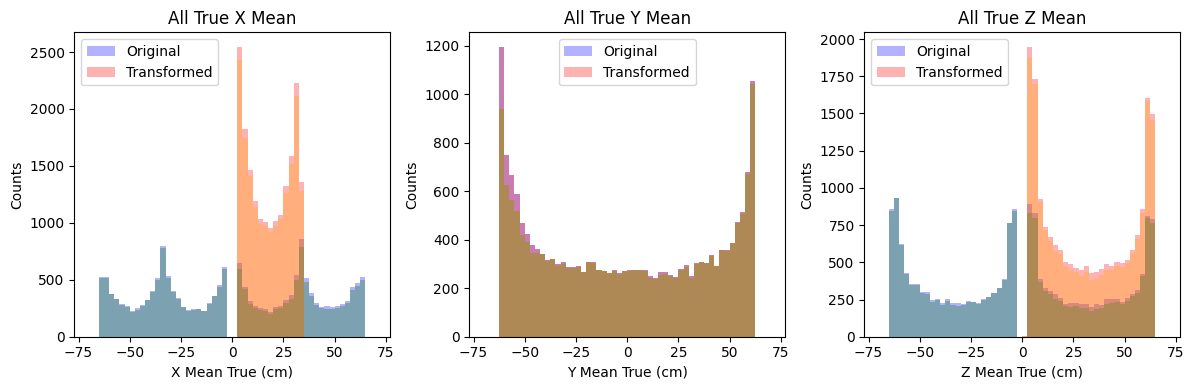

In [30]:
# plot histogram of all true in x y z
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.hist(all_true['x_wmean_int'].dropna(), bins=xbins, color='blue', alpha=0.3)
plt.hist(all_true['x_wmean_int_trfm'].dropna(), bins=xbins, color='red', alpha=0.3)
plt.hist(det_true_rec['x_wmean_int'].dropna(), bins=xbins, color='green', alpha=0.3)
plt.hist(det_true_rec['x_wmean_int_trfm'].dropna(), bins=xbins, color='orange', alpha=0.3)
plt.xlabel('X Mean True (cm)')
plt.ylabel('Counts')
plt.title('All True X Mean')
plt.legend(['Original', 'Transformed'])
plt.subplot(1, 3, 2)
plt.hist(all_true['y_wmean_int'].dropna(), bins=ybins, color='blue', alpha=0.3)
plt.hist(all_true['y_wmean_int_trfm'].dropna(), bins=ybins, color='red', alpha=0.3)
plt.hist(det_true_rec['y_wmean_int'].dropna(), bins=ybins, color='green', alpha=0.3)
plt.hist(det_true_rec['y_wmean_int_trfm'].dropna(), bins=ybins, color='orange', alpha=0.3)
plt.xlabel('Y Mean True (cm)')
plt.ylabel('Counts')
plt.title('All True Y Mean')
plt.legend(['Original', 'Transformed'])
plt.subplot(1, 3, 3)
plt.hist(all_true['z_wmean_int'].dropna(), bins=zbins, color='blue', alpha=0.3)
plt.hist(all_true['z_wmean_int_trfm'].dropna(), bins=zbins, color='red', alpha=0.3)
plt.hist(det_true_rec['z_wmean_int'].dropna(), bins=zbins, color='green', alpha=0.3)
plt.hist(det_true_rec['z_wmean_int_trfm'].dropna(), bins=zbins, color='orange', alpha=0.3)
plt.xlabel('Z Mean True (cm)')
plt.ylabel('Counts')
plt.title('All True Z Mean')
plt.legend(['Original', 'Transformed'])
plt.tight_layout()
plt.show()

In [31]:
# test the 3D slice plotting function
anim_efficiency = plot_3d_efficiency_slices(
    x_A=det_true_reco_x_trfm,
    y_A=det_true_reco_y_trfm,
    z_A=det_true_reco_z_trfm,
    x_B=all_true_x_trfm,
    y_B=all_true_y_trfm,
    z_B=all_true_z_trfm,
    bins_x=xbinst,
    bins_y=ybinst,
    bins_z=zbinst,
    xlabel_list=['X Mean (cm)', 'X Mean (cm)', 'Y Mean (cm)'],
    ylabel_list=['Y Mean (cm)', 'Z Mean (cm)', 'Z Mean (cm)'],
    clabel='Efficiency',
    #neg=True,
    slice_axis='x',
    interval=200,
    bin_mask=bin_mask_3d,
    save_gif='efficiency_xslices.gif',
    fps=2
)

# test the 3D slice plotting function
anim_efficiency = plot_3d_efficiency_slices(
    x_A=det_true_reco_x_trfm,
    y_A=det_true_reco_y_trfm,
    z_A=det_true_reco_z_trfm,
    x_B=all_true_x_trfm,
    y_B=all_true_y_trfm,
    z_B=all_true_z_trfm,
    bins_x=xbinst,
    bins_y=ybinst,
    bins_z=zbinst,
    xlabel_list=['X Mean (cm)', 'X Mean (cm)', 'Y Mean (cm)'],
    ylabel_list=['Y Mean (cm)', 'Z Mean (cm)', 'Z Mean (cm)'],
    clabel='Efficiency',
    #neg=True,
    slice_axis='y',
    interval=200,
    bin_mask=bin_mask_3d,
    save_gif='efficiency_yslices.gif',
    fps=2
)

# test the 3D slice plotting function
anim_efficiency = plot_3d_efficiency_slices(
    x_A=det_true_reco_x_trfm,
    y_A=det_true_reco_y_trfm,
    z_A=det_true_reco_z_trfm,
    x_B=all_true_x_trfm,
    y_B=all_true_y_trfm,
    z_B=all_true_z_trfm,
    bins_x=xbinst,
    bins_y=ybinst,
    bins_z=zbinst,
    xlabel_list=['X Mean (cm)', 'X Mean (cm)', 'Y Mean (cm)'],
    ylabel_list=['Y Mean (cm)', 'Z Mean (cm)', 'Z Mean (cm)'],
    clabel='Efficiency',
    #neg=True,
    slice_axis='z',
    interval=200,
    bin_mask=bin_mask_3d,
    save_gif='efficiency_zslices.gif',
    fps=2
)

/tmp/ipykernel_1682501/1080874041.py:80: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis').copy()


Saved GIF to: efficiency_xslices.gif


/tmp/ipykernel_1682501/1080874041.py:80: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis').copy()


Saved GIF to: efficiency_yslices.gif


/tmp/ipykernel_1682501/1080874041.py:80: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis').copy()


Saved GIF to: efficiency_zslices.gif


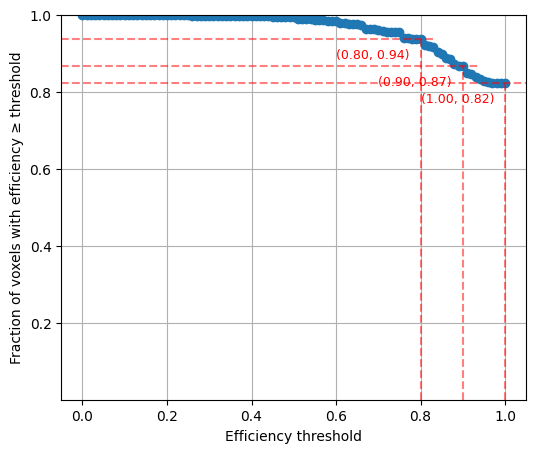

In [32]:
# plot CDF of the fraction of voxels with efficiency > threshold
def plot_efficiency_cdf(
    x_A, y_A, z_A,
    x_B, y_B, z_B,
    bins_x, bins_y, bins_z,
    thresholds=np.linspace(0, 1, 101),
    vlines=None
):
    hist_A, _ = np.histogramdd(
        np.vstack((x_A, y_A, z_A)).T,
        bins=[bins_x, bins_y, bins_z]
    )
    hist_B, _ = np.histogramdd(
        np.vstack((x_B, y_B, z_B)).T,
        bins=[bins_x, bins_y, bins_z]
    )
    eff = np.divide(
        hist_A,
        hist_B,
        out=np.zeros_like(hist_A, dtype=float),
        where=hist_B != 0
    )
    eff_flat = eff.flatten()
    eff_flat = eff_flat[hist_B.flatten() > 0]  # consider only voxels with data

    cdf_values = []
    for thr in thresholds:
        frac = np.sum(eff_flat >= thr) / len(eff_flat)
        cdf_values.append(frac)

    plt.figure(figsize=(6, 5))
    plt.plot(thresholds, cdf_values, marker='o')
    plt.xlabel('Efficiency threshold')
    plt.ylabel('Fraction of voxels with efficiency ≥ threshold')
    for vline in (vlines or []):
      plt.axvline(x=vline, color='r', linestyle='--', alpha=0.5, ymax=(np.interp(vline, thresholds, cdf_values)))
      # Find the y-value at this x threshold
      idx = np.argmin(np.abs(thresholds - vline))
      y_val = cdf_values[idx]
      # Draw horizontal line to the curve
      plt.axhline(y=y_val, color='r', linestyle='--', alpha=0.5, xmax=(vline - thresholds[0]) / (thresholds[-1] - thresholds[0]))
      # Add text labels
      plt.text(vline - 0.2, y_val - 0.05, f'({vline:.2f}, {y_val:.2f})', color='r', fontsize=9)
    plt.grid()
    #plt.yscale('log')
    plt.ylim(1e-4, 1.0)
    plt.show()

plot_efficiency_cdf(
    x_A=det_true_reco_x_trfm,
    y_A=det_true_reco_y_trfm,
    z_A=det_true_reco_z_trfm,
    x_B=all_true_x_trfm,
    y_B=all_true_y_trfm,
    z_B=all_true_z_trfm,
    bins_x=xbinst,
    bins_y=ybinst,
    bins_z=zbinst,
    vlines = [0.8, 0.9, 1.00]
)

In [33]:
# Transform all_true and det_true_rec with align_params
all_true, align_params = transform_positions(
  all_true,
  tpc_bounds_mm=tpc_bounds_cm,
  x_col='x_wmean_int',
  y_col='y_wmean_int',
  z_col='z_wmean_int',
  out_x='x_wmean_int_trfm',
  out_y='y_wmean_int_trfm',
  out_z='z_wmean_int_trfm',
  return_params=True
)

det_true_rec = apply_transform(
  det_true_rec,
  params=align_params,
  x_col='x_wmean_int',
  y_col='y_wmean_int',
  z_col='z_wmean_int',
  out_x='x_wmean_int_trfm',
  out_y='y_wmean_int_trfm',
  out_z='z_wmean_int_trfm',
)

# Define module groupings: each module = pair of TPCs
modules = [(0, 1), (2, 3), (4, 5), (6, 7)]
module_names = ['Module 0', 'Module 1', 'Module 2', 'Module 3']

# Store per-module data
all_true_x_trfm_mod = []
det_true_reco_x_trfm_mod = []
all_true_y_trfm_mod = []
det_true_reco_y_trfm_mod = []
all_true_z_trfm_mod = []
det_true_reco_z_trfm_mod = []

for i, (tpc0, tpc1) in enumerate(modules):
  # Filter by module (TPCs in the pair)
  all_true_mod = all_true[all_true['tpc_num'].isin([float(tpc0), float(tpc1)])]
  det_true_rec_mod = det_true_rec[det_true_rec['tpc_num'].isin([float(tpc0), float(tpc1)])]

  # Extract transformed coordinates per module
  all_true_x_trfm_mod.append(all_true_mod['x_wmean_int_trfm'].dropna())
  det_true_reco_x_trfm_mod.append(det_true_rec_mod['x_wmean_int_trfm'].dropna())
  all_true_y_trfm_mod.append(all_true_mod['y_wmean_int_trfm'].dropna())
  det_true_reco_y_trfm_mod.append(det_true_rec_mod['y_wmean_int_trfm'].dropna())
  all_true_z_trfm_mod.append(all_true_mod['z_wmean_int_trfm'].dropna())
  det_true_reco_z_trfm_mod.append(det_true_rec_mod['z_wmean_int_trfm'].dropna())

  print(f"{module_names[i]} (TPC {tpc0},{tpc1}): {len(all_true_mod)} truth, {len(det_true_rec_mod)} det_true_rec")

# Also keep overall data (as before)
all_true_x_trfm = all_true['x_wmean_int_trfm'].dropna()
det_true_reco_x_trfm = det_true_rec['x_wmean_int_trfm'].dropna()
all_true_y_trfm = all_true['y_wmean_int_trfm'].dropna()
det_true_reco_y_trfm = det_true_rec['y_wmean_int_trfm'].dropna()
all_true_z_trfm = all_true['z_wmean_int_trfm'].dropna()
det_true_reco_z_trfm = det_true_rec['z_wmean_int_trfm'].dropna()

Module 0 (TPC 0,1): 4418 truth, 3922 det_true_rec
Module 1 (TPC 2,3): 4862 truth, 4747 det_true_rec
Module 2 (TPC 4,5): 4501 truth, 4395 det_true_rec
Module 3 (TPC 6,7): 4816 truth, 4705 det_true_rec


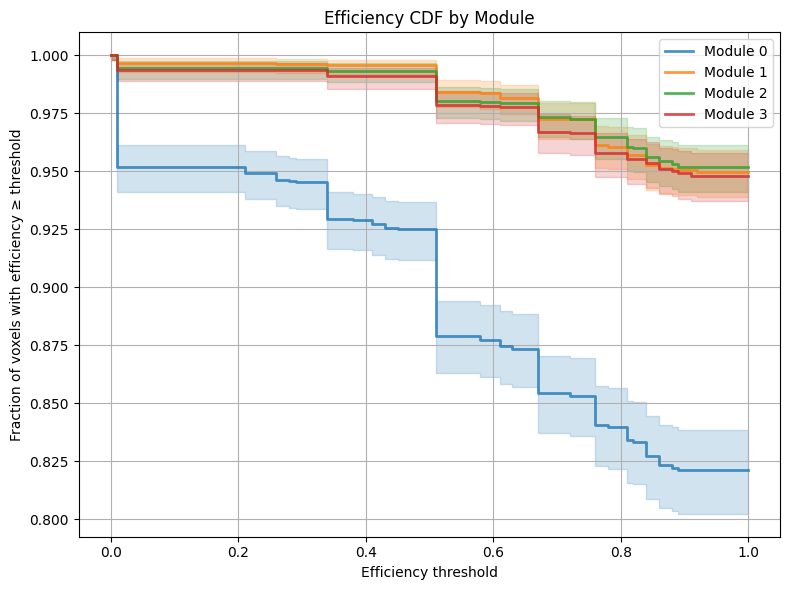

In [34]:
# Plot efficiency CDF for each module
def plot_efficiency_cdf_modules(
  x_A_list, y_A_list, z_A_list,
  x_B_list, y_B_list, z_B_list,
  bins_x, bins_y, bins_z,
  legend_labels,
  colors,
  thresholds=np.linspace(0, 1, 101),
  vlines=None,
  alpha=0.05
):
  """
  Plot efficiency CDFs for multiple modules/groups on the same plot.

  Parameters
  ----------
  x_A_list, y_A_list, z_A_list : list of arrays
    List of reconstructed (numerator) data for each module
  x_B_list, y_B_list, z_B_list : list of arrays
    List of truth (denominator) data for each module
  legend_labels : list of str
    Labels for each module
  colors : list
    Colors for each module line
  alpha : float
    Significance level for Clopper-Pearson confidence intervals
  """
  plt.figure(figsize=(8, 6))

  for i, (x_A, y_A, z_A, x_B, y_B, z_B, label, color) in enumerate(
    zip(x_A_list, y_A_list, z_A_list,
      x_B_list, y_B_list, z_B_list,
      legend_labels, colors)
  ):
    hist_A, _ = np.histogramdd(
      np.vstack((x_A, y_A, z_A)).T,
      bins=[bins_x, bins_y, bins_z]
    )
    hist_B, _ = np.histogramdd(
      np.vstack((x_B, y_B, z_B)).T,
      bins=[bins_x, bins_y, bins_z]
    )
    eff = np.divide(
      hist_A,
      hist_B,
      out=np.zeros_like(hist_A, dtype=float),
      where=hist_B != 0
    )
    eff_flat = eff.flatten()
    hist_B_flat = hist_B.flatten()

    # Only consider voxels with data
    mask = hist_B_flat > 0
    eff_flat = eff_flat[mask]
    hist_A_flat = hist_A.flatten()[mask]
    hist_B_flat = hist_B_flat[mask]

    n_voxels = len(eff_flat)

    cdf_values = []
    lower_bounds = []
    upper_bounds = []

    for thr in thresholds:
      # Count voxels with efficiency >= threshold
      n_success = np.sum(eff_flat >= thr)
      frac = n_success / n_voxels if n_voxels > 0 else 0
      cdf_values.append(frac)

      # Clopper-Pearson interval for binomial proportion
      lower, upper = clopper_pearson_interval_numpy(
        np.array([n_success]),
        np.array([n_voxels]),
        alpha=alpha
      )
      lower_bounds.append(lower[0])
      upper_bounds.append(upper[0])

    # Convert to arrays for plotting
    cdf_values = np.array(cdf_values)
    lower_bounds = np.array(lower_bounds)
    upper_bounds = np.array(upper_bounds)

    # Step plot for CDF
    plt.step(thresholds, cdf_values, where='post', label=label, color=color, alpha=0.8, linewidth=2)

    # Fill between for confidence intervals
    plt.fill_between(thresholds, lower_bounds, upper_bounds,
                     step='post', alpha=0.2, color=color)

  # Add vlines if specified
  if vlines:
    for vline in vlines:
      plt.axvline(x=vline, color='gray', linestyle='--', alpha=0.3)

  plt.xlabel('Efficiency threshold')
  plt.ylabel('Fraction of voxels with efficiency ≥ threshold')
  #plt.yscale('log')
  #plt.ylim(1e-4, 1.0)
  plt.grid()
  plt.legend()
  plt.title('Efficiency CDF by Module')
  plt.tight_layout()
  plt.show()

# Plot for all modules
colors_mod = [plt.cm.tab10(i % 10) for i in range(len(modules))]

plot_efficiency_cdf_modules(
  x_A_list=det_true_reco_x_trfm_mod,
  y_A_list=det_true_reco_y_trfm_mod,
  z_A_list=det_true_reco_z_trfm_mod,
  x_B_list=all_true_x_trfm_mod,
  y_B_list=all_true_y_trfm_mod,
  z_B_list=all_true_z_trfm_mod,
  bins_x=xbinst,
  bins_y=ybinst,
  bins_z=zbinst,
  legend_labels=module_names,
  colors=colors_mod,
  #vlines=[0.8, 0.9, 1.00]
)

In [35]:
def plot_efficiency_quantiles_vs_energy(
  x_A_list, y_A_list, z_A_list,
  x_B_list, y_B_list, z_B_list,
  bins_x, bins_y, bins_z,
  energy_thresholds=None,
  quantiles=np.array([0.1, 0.25, 0.5, 0.75, 0.9]),
  cmap='viridis',
  logx=False,
  logy=False,
  logz=False
):
    """
    Plot efficiency threshold vs energy for different voxel quantiles.

    For each quantile, plots the minimum efficiency threshold such that
    that fraction of voxels has efficiency >= threshold.

    Parameters
    ----------
    x_A_list, y_A_list, z_A_list : list of array-like
      Lists of numerator datasets (successful events)
    x_B_list, y_B_list, z_B_list : list of array-like
      Lists of denominator datasets (all events)
    bins_x, bins_y, bins_z : array-like
      Bin edges for each dimension
    energy_thresholds : array-like
      Energy values for x-axis (same length as datasets)
    quantiles : array-like
      Voxel fraction quantiles to plot (e.g., 0.5 = median voxel efficiency)
    cmap : str
      Matplotlib colormap name
    logx, logy, logz : bool
      Whether to use log scale for x, y axes and colorbar
    """
    from matplotlib.colors import ListedColormap, LogNorm, Normalize
    n_datasets = len(x_A_list)
    if energy_thresholds is None:
        energy_thresholds = np.arange(n_datasets)

    # Create colormap for quantiles
    cmap_continuous = plt.colormaps.get_cmap(cmap)

    # Create norm based on logz parameter
    if logz:
        norm = LogNorm(vmin=np.min(quantiles), vmax=np.max(quantiles))
    else:
        norm = Normalize(vmin=np.min(quantiles), vmax=np.max(quantiles))

    colors = [cmap_continuous(norm(val)) for val in quantiles]

    # Create discrete colormap for the colorbar
    discrete_cmap = ListedColormap(colors)
    sm = plt.cm.ScalarMappable(cmap=discrete_cmap, norm=norm)

    plt.figure(figsize=(8, 6))

    # For each quantile, compute efficiency threshold vs energy
    for q_idx, quantile in enumerate(quantiles):
        efficiency_thresholds_for_quantile = []

        for i in range(n_datasets):
            # Compute efficiency for this energy threshold
            hist_A, _ = np.histogramdd(
                np.vstack((x_A_list[i], y_A_list[i], z_A_list[i])).T,
                bins=[bins_x, bins_y, bins_z]
            )
            hist_B, _ = np.histogramdd(
                np.vstack((x_B_list[i], y_B_list[i], z_B_list[i])).T,
                bins=[bins_x, bins_y, bins_z]
            )
            eff = np.divide(
                hist_A,
                hist_B,
                out=np.zeros_like(hist_A, dtype=float),
                where=hist_B != 0
            )
            eff_flat = eff.flatten()
            eff_flat = eff_flat[hist_B.flatten() > 0]

            # Find efficiency threshold where this quantile of voxels exceed it
            # quantile=0.9 means 90% of voxels have efficiency >= this threshold
            # This corresponds to the (1-0.9)=0.1 percentile of the efficiency distribution
            eff_threshold = np.percentile(eff_flat, (1 - quantile) * 100)
            efficiency_thresholds_for_quantile.append(eff_threshold)

        plt.plot(
            energy_thresholds,
            efficiency_thresholds_for_quantile,
            marker='o',
            color=colors[q_idx],
            alpha=0.7,
            label=f'{quantile:.0%} of voxels'
        )

    plt.xlabel('Energy threshold [MeV]')
    plt.ylabel('Efficiency threshold')
    plt.grid(alpha=0.3)

    if logx:
        plt.xscale('log')
    if logy:
        plt.yscale('log')

    plt.tight_layout()

    cbar = plt.colorbar(sm, pad=0.02, ax=plt.gca())
    cbar.set_label('Voxel quantile')

    plt.show()

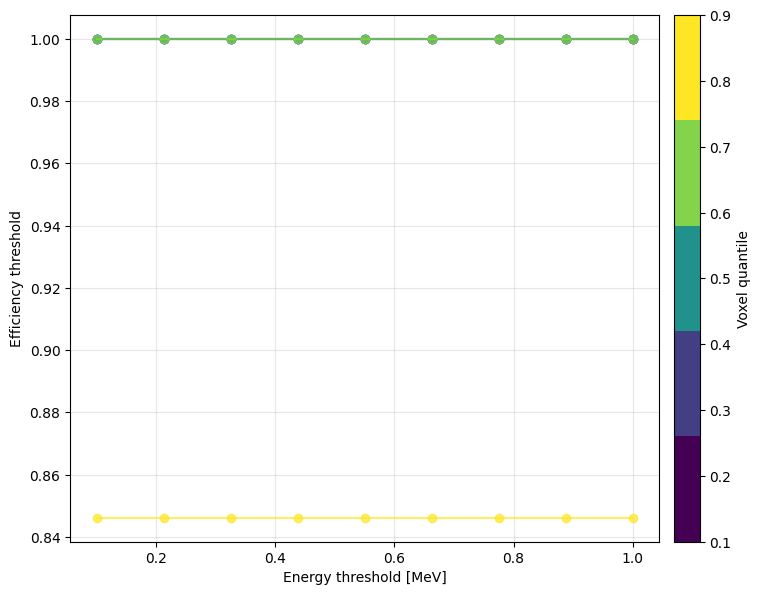

In [36]:
# Example usage of plot_efficiency_quantiles_vs_energy
energy_thresholds_MeV = np.linspace(0.1, 1.0, 9)
det_true_reco_x_trfms = []
det_true_reco_y_trfms = []
det_true_reco_z_trfms = []
all_true_x_trfms = []
all_true_y_trfms = []
all_true_z_trfms = []

for ethr in energy_thresholds_MeV:
    det_true_reco_x_trfms.append(
        det_true_reco_x_trfm[det_true_rec['dE_tot'] >= ethr]
    )
    det_true_reco_y_trfms.append(
        det_true_reco_y_trfm[det_true_rec['dE_tot'] >= ethr]
    )
    det_true_reco_z_trfms.append(
        det_true_reco_z_trfm[det_true_rec['dE_tot'] >= ethr]
    )
    all_true_x_trfms.append(
        all_true_x_trfm[all_true['dE_tot'] >= ethr]
    )
    all_true_y_trfms.append(
        all_true_y_trfm[all_true['dE_tot'] >= ethr]
    )
    all_true_z_trfms.append(
        all_true_z_trfm[all_true['dE_tot'] >= ethr]
    )


plot_efficiency_quantiles_vs_energy(
    x_A_list=det_true_reco_x_trfms,
    y_A_list=det_true_reco_y_trfms,
    z_A_list=det_true_reco_z_trfms,
    x_B_list=all_true_x_trfms,
    y_B_list=all_true_y_trfms,
    z_B_list=all_true_z_trfms,
    bins_x=xbinst,
    bins_y=ybinst,
    bins_z=zbinst,
    energy_thresholds=energy_thresholds_MeV,
    quantiles=np.array([0.1, 0.25, 0.5, 0.75, 0.9]),
    logx=False,
    logy=False,
    logz=False
)